In [19]:
import os
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_olivetti_faces
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, accuracy_score, roc_curve, auc
from sklearn.preprocessing import StandardScaler, label_binarize
from itertools import cycle


Dataset loaded: 400 images, 4096 features per image
Number of subjects: 40


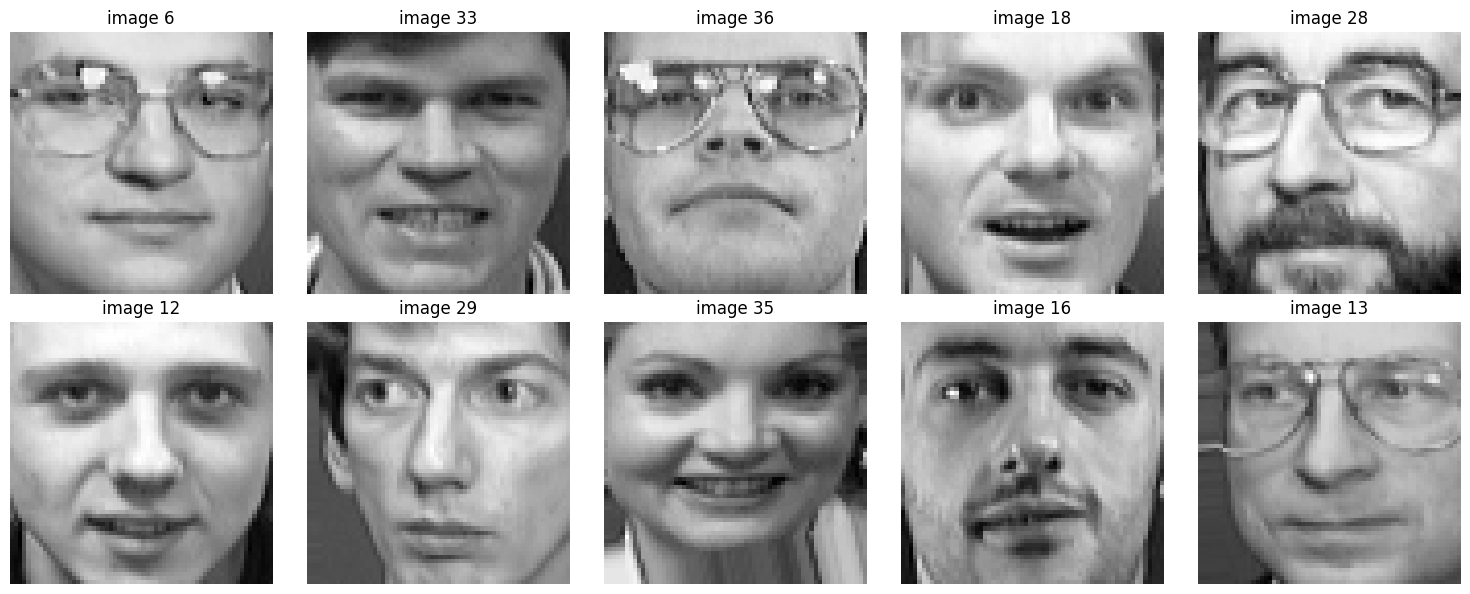

In [22]:
# Load ORL/AT&T dataset
dataset = fetch_olivetti_faces(shuffle=False)
X = (dataset.data * 255).astype(np.float64)  # (400, 4096)
y = dataset.target                             # (400,)

print(f"Dataset loaded: {X.shape[0]} images, {X.shape[1]} features per image")
print(f"Number of subjects: {len(np.unique(y))}")

# Visualize sample faces
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
axes = axes.flatten()

for i in range(10):
    idx = np.random.randint(0, X.shape[0])
    face = X[idx].reshape(64, 64)
    axes[i].imshow(face, cmap='gray')
    axes[i].set_title(f"image {y[idx]+1}")
    axes[i].axis('off')

plt.tight_layout()
plt.show()

In [23]:

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

print(f"Training set size: {X_train.shape[0]} images")
print(f"Testing set size:  {X_test.shape[0]} images")

Training set size: 280 images
Testing set size:  120 images


In [24]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print(f"Training data mean (after scaling): {X_train_scaled.mean():.6f}")
print(f"Training data std  (after scaling): {X_train_scaled.std():.6f}")
print("Standardization complete!")

Training data mean (after scaling): -0.000000
Training data std  (after scaling): 1.000000
Standardization complete!


In [25]:
# Create a custom PCA implementation from scratch
class CustomPCA:
    def __init__(self, n_components=None):
        self.n_components = n_components
        self.components_ = None
        self.explained_variance_ = None
        self.explained_variance_ratio_ = None
        self.mean_ = None

    def fit_transform(self, X):
        # Store the mean
        self.mean_ = np.mean(X, axis=0)

        # Center the data
        X_centered = X - self.mean_

        # Calculate the covariance matrix
        n_samples = X_centered.shape[0]
        cov_matrix = np.dot(X_centered.T, X_centered) / (n_samples - 1)

        # Compute eigenvalues and eigenvectors
        eigenvalues, eigenvectors = np.linalg.eigh(cov_matrix)

        # Sort in decreasing order
        idx = np.argsort(eigenvalues)[::-1]
        eigenvalues  = eigenvalues[idx]
        eigenvectors = eigenvectors[:, idx]

        # Calculate explained variance ratio
        total_var = np.sum(eigenvalues)
        self.explained_variance_       = eigenvalues
        self.explained_variance_ratio_ = eigenvalues / total_var

        # Determine number of components based on variance threshold
        if isinstance(self.n_components, float) and self.n_components < 1:
            cumulative_variance = np.cumsum(self.explained_variance_ratio_)
            self.n_components = np.argmax(cumulative_variance >= self.n_components) + 1

        # Select top k eigenvectors
        self.components_ = eigenvectors[:, :self.n_components].T

        # Project the data
        return np.dot(X_centered, eigenvectors[:, :self.n_components])

    def transform(self, X):
        X_centered = X - self.mean_
        return np.dot(X_centered, self.components_.T)


# Apply Custom PCA with 90% variance threshold
custom_pca = CustomPCA(n_components=0.90)
X_train_pca = custom_pca.fit_transform(X_train_scaled)
X_test_pca  = custom_pca.transform(X_test_scaled)

print(f"Original dimensionality : {X_train.shape[1]}")
print(f"Reduced dimensionality  : {X_train_pca.shape[1]}")
print(f"Explained variance ratio: {sum(custom_pca.explained_variance_ratio_[:custom_pca.n_components]):.4f}")

Original dimensionality : 4096
Reduced dimensionality  : 59
Explained variance ratio: 0.9011


Displaying 59 eigenfaces


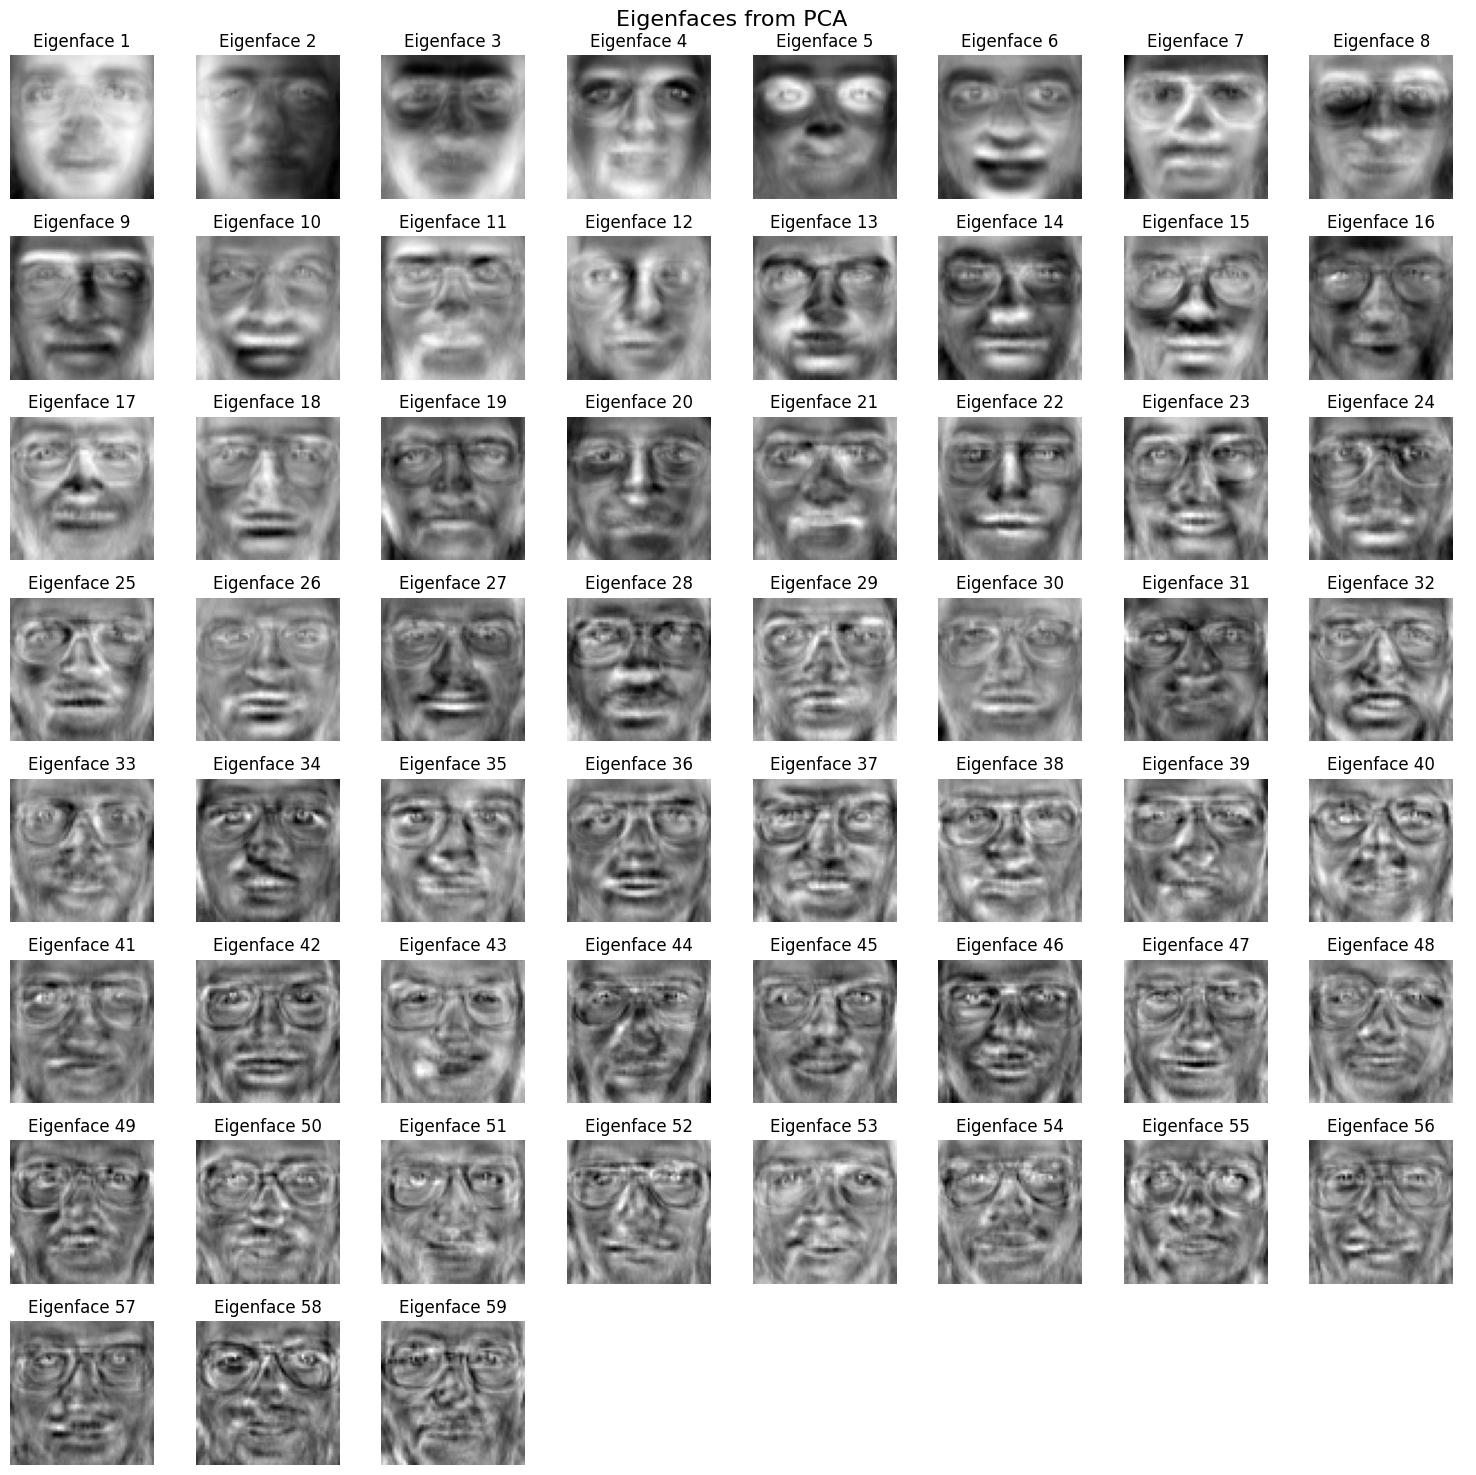

In [26]:
# Get the number of components from custom PCA
n_components = custom_pca.n_components
print(f"Displaying {n_components} eigenfaces")

# Calculate the grid size needed
grid_size = int(np.ceil(np.sqrt(n_components)))
fig, axes = plt.subplots(grid_size, grid_size, figsize=(15, 15))
axes = axes.flatten()

for i in range(min(n_components, len(axes))):
    eigenface = custom_pca.components_[i].reshape(64, 64)
    axes[i].imshow(eigenface, cmap='gray')
    axes[i].set_title(f"Eigenface {i+1}")
    axes[i].axis('off')

# Turn off axes for unused subplots
for i in range(min(n_components, len(axes)), len(axes)):
    axes[i].axis('off')

plt.suptitle("Eigenfaces from PCA", fontsize=16)
plt.tight_layout()
plt.subplots_adjust(top=0.95)
plt.show()

In [27]:
# Train KNN classifier (built-in) — replacing SVM from notebook
classifier = KNeighborsClassifier(n_neighbors=1, metric='euclidean')
classifier.fit(X_train_pca, y_train)

print("KNN Classifier trained successfully!")
print(f"  K value  : 1")
print(f"  Metric   : Euclidean")
print(f"  Train set: {X_train_pca.shape[0]} samples in {X_train_pca.shape[1]}D PCA space")

KNN Classifier trained successfully!
  K value  : 1
  Metric   : Euclidean
  Train set: 280 samples in 59D PCA space


In [28]:
# Predict on test set
y_pred = classifier.predict(X_test_pca)

# Accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.2f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.93

Classification Report:
              precision    recall  f1-score   support

           0       0.50      0.33      0.40         3
           1       1.00      1.00      1.00         3
           2       1.00      1.00      1.00         3
           3       1.00      0.33      0.50         3
           4       1.00      0.67      0.80         3
           5       1.00      1.00      1.00         3
           6       1.00      1.00      1.00         3
           7       0.67      0.67      0.67         3
           8       1.00      1.00      1.00         3
           9       1.00      0.33      0.50         3
          10       1.00      1.00      1.00         3
          11       1.00      1.00      1.00         3
          12       0.75      1.00      0.86         3
          13       1.00      1.00      1.00         3
          14       1.00      1.00      1.00         3
          15       1.00      1.00      1.00         3
          16       1.00      1.00      1.0

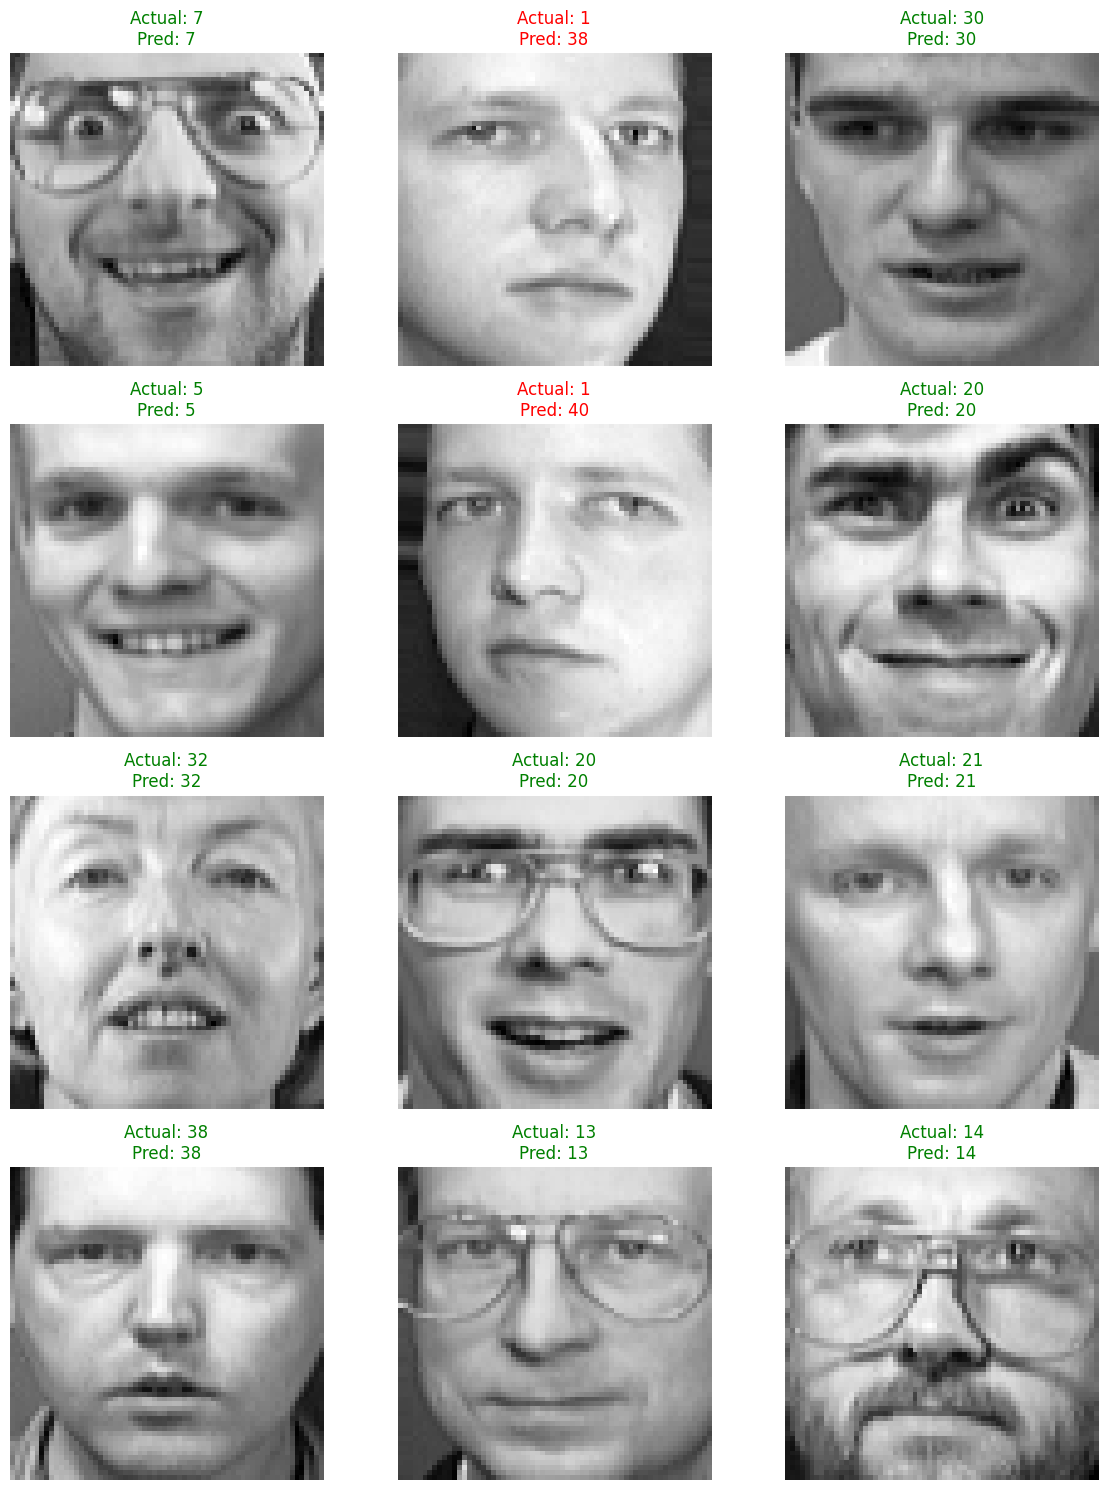

In [29]:
# Visualize some predictions
fig, axes = plt.subplots(4, 3, figsize=(12, 15))
axes = axes.flatten()

# Get some random test samples
indices = np.random.choice(range(len(X_test)), 12, replace=False)

for i, idx in enumerate(indices):
    face = X_test[idx].reshape(64, 64)
    axes[i].imshow(face, cmap='gray')
    correct = y_test[idx] == y_pred[idx]
    color = 'green' if correct else 'red'
    axes[i].set_title(f"Actual: {y_test[idx]+1}\nPred: {y_pred[idx]+1}", color=color)
    axes[i].axis('off')

plt.tight_layout()
plt.show()

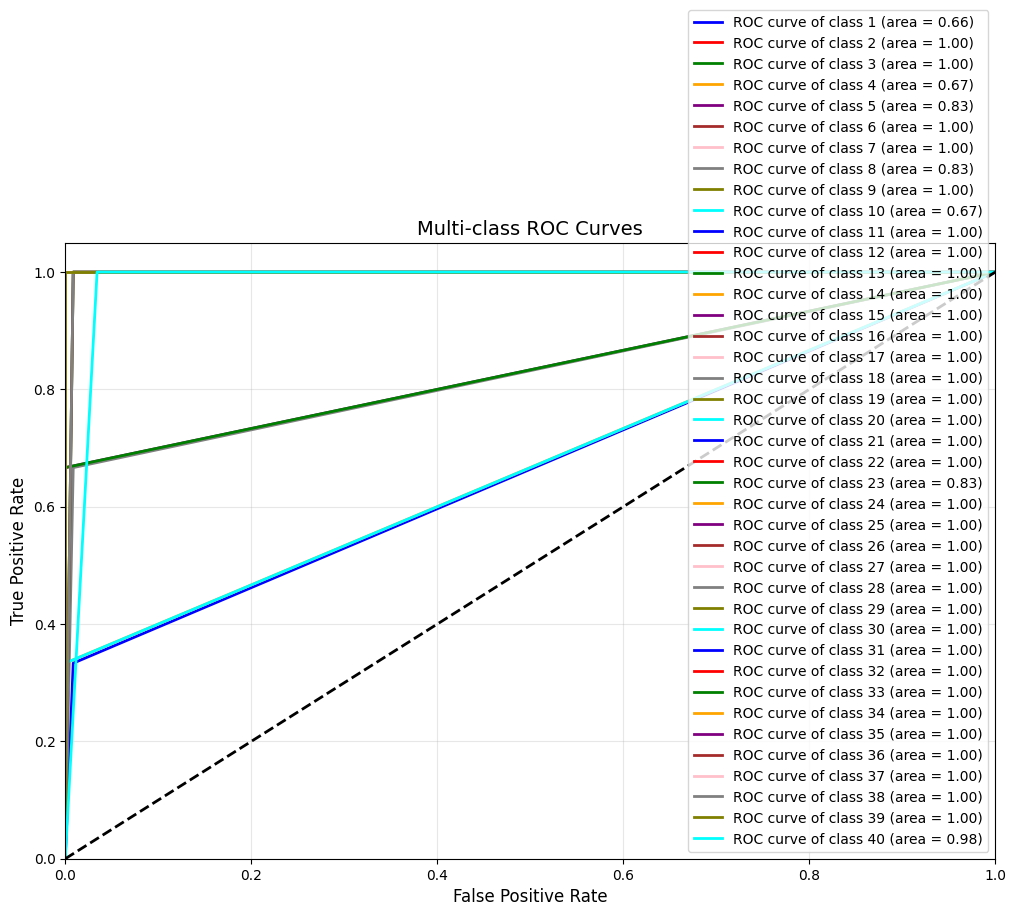

In [30]:
# Binarize the output labels for ROC curve calculation
classes = np.unique(y)
n_classes = len(classes)
y_test_bin = label_binarize(y_test, classes=classes)

# For KNN use predict_proba instead of decision_function
y_score = classifier.predict_proba(X_test_pca)

# Compute ROC curve and AUC for each class
fpr = {}
tpr = {}
roc_auc = {}

for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_score[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Plot all ROC curves
plt.figure(figsize=(12, 8))
colors = cycle(['blue', 'red', 'green', 'orange', 'purple',
                'brown', 'pink', 'gray', 'olive', 'cyan'])

for i, color in zip(range(n_classes), colors):
    plt.plot(fpr[i], tpr[i], color=color, lw=2,
             label='ROC curve of class {0} (area = {1:0.2f})'.format(i+1, roc_auc[i]))

plt.plot([0, 1], [0, 1], 'k--', lw=2)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('Multi-class ROC Curves', fontsize=14)
plt.legend(loc="lower right")
plt.grid(True, alpha=0.3)
plt.show()

Components:   5, Accuracy: 0.7917, Variance Explained: 0.5518
Components:  10, Accuracy: 0.8917, Variance Explained: 0.6642
Components:  15, Accuracy: 0.9250, Variance Explained: 0.7298
Components:  20, Accuracy: 0.9167, Variance Explained: 0.7713
Components:  25, Accuracy: 0.9250, Variance Explained: 0.8018
Components:  30, Accuracy: 0.9250, Variance Explained: 0.8255
Components:  40, Accuracy: 0.9250, Variance Explained: 0.8596
Components:  50, Accuracy: 0.9333, Variance Explained: 0.8840
Components:  60, Accuracy: 0.9250, Variance Explained: 0.9027
Components:  70, Accuracy: 0.9250, Variance Explained: 0.9173
Components:  80, Accuracy: 0.9250, Variance Explained: 0.9293
Components:  90, Accuracy: 0.9250, Variance Explained: 0.9392


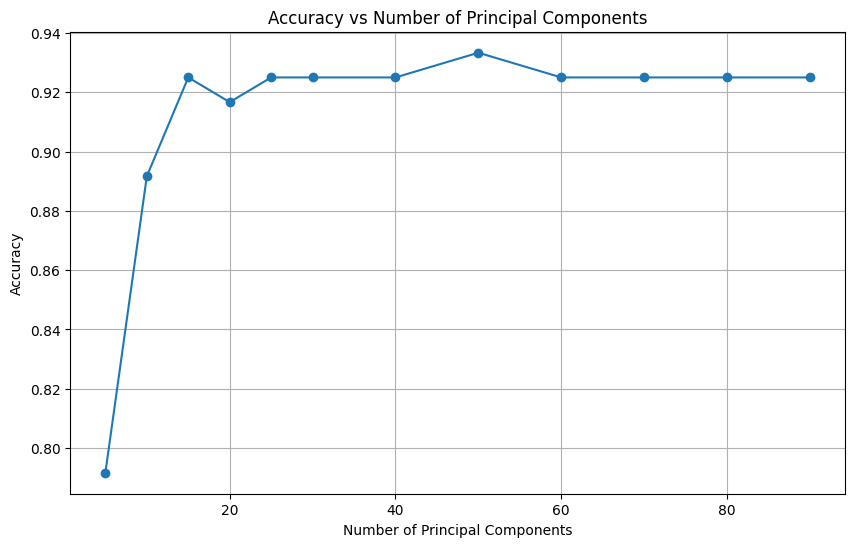

In [31]:
n_components_list = [5, 10, 15, 20, 25, 30, 40, 50, 60, 70, 80, 90]
accuracies = []

for n_comp in n_components_list:
    # Apply Custom PCA
    pca_exp = CustomPCA(n_components=n_comp)
    X_train_pca_exp = pca_exp.fit_transform(X_train_scaled)
    X_test_pca_exp  = pca_exp.transform(X_test_scaled)

    # Train KNN
    knn_exp = KNeighborsClassifier(n_neighbors=1, metric='euclidean')
    knn_exp.fit(X_train_pca_exp, y_train)

    # Evaluate
    y_pred_exp = knn_exp.predict(X_test_pca_exp)
    accuracy   = accuracy_score(y_test, y_pred_exp)
    accuracies.append(accuracy)

    var_explained = sum(pca_exp.explained_variance_ratio_[:n_comp])
    print(f"Components: {n_comp:3d}, Accuracy: {accuracy:.4f}, Variance Explained: {var_explained:.4f}")

# Plot accuracy vs number of components
plt.figure(figsize=(10, 6))
plt.plot(n_components_list, accuracies, marker='o')
plt.grid(True)
plt.title('Accuracy vs Number of Principal Components')
plt.xlabel('Number of Principal Components')
plt.ylabel('Accuracy')
plt.show()

In [32]:
import pickle

# Create directory for saved models
if not os.path.exists('saved_model'):
    os.makedirs('saved_model')

# Save all components
with open('saved_model/knn_classifier.pkl', 'wb') as f:
    pickle.dump(classifier, f)

with open('saved_model/pca_model.pkl', 'wb') as f:
    pickle.dump(custom_pca, f)

with open('saved_model/scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

print("Model and preprocessing components saved successfully!")

# Verify by reloading
with open('saved_model/knn_classifier.pkl', 'rb') as f:
    loaded_knn = pickle.load(f)

with open('saved_model/pca_model.pkl', 'rb') as f:
    loaded_pca = pickle.load(f)

with open('saved_model/scaler.pkl', 'rb') as f:
    loaded_scaler = pickle.load(f)

# Quick test with loaded model
y_pred_loaded = loaded_knn.predict(loaded_pca.transform(loaded_scaler.transform(X_test)))
print(f"Verification accuracy: {accuracy_score(y_test, y_pred_loaded):.2f}")

# Download all files
from google.colab import files
files.download('saved_model/knn_classifier.pkl')
files.download('saved_model/pca_model.pkl')
files.download('saved_model/scaler.pkl')

print("\n✅ All files downloaded!")

Model and preprocessing components saved successfully!
Verification accuracy: 0.93


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


✅ All files downloaded!
